In [1]:
import numpy as np
import matplotlib.pyplot as plt

from impulse import PTSampler

%load_ext autoreload
%autoreload 2

### Simulate data with signal and noise

Let's simulate some data as

$d_i(t) = n_i + s_i(t)\, ,$

with

$n_i \sim \mathcal{N}(0, 1)\, ,$

where $d_i(t)$ are the i-th data point, $n_i$ is the noise, and $s_i(t)$ is the signal. The signal is

$s_i\left([A, f, \phi]; t\right) = A \sin(2\pi f t + \phi)$.

### Serial evaluation of the likelihood

In [2]:
def make_sine_data(num_pts):
    rng = np.random.default_rng()

    omega_real = 3 * rng.uniform(0, 1)
    a_real = 5 * rng.uniform(0, 1)
    phi_real = np.pi * rng.uniform(0, 1)

    x = np.linspace(0, 2*np.pi, num_pts)
    data = rng.standard_normal(num_pts) + a_real * np.sin(omega_real * x + phi_real)
    return x, data, omega_real, a_real, phi_real

# standard least squares likelihood
class LnLikelihood():
    def __init__(self, x, data, sigma=1):
        self.x = x
        self.sigma = sigma
        self.data = data

    def __call__(self, params):
        omega = params[0]
        a = params[1]
        phi = params[2]
        func = a * np.sin(omega * self.x + phi)
        if np.isnan(func).any():
            print(a, omega, phi, func)
        result = np.sum(-0.5 * ((func - self.data) / self.sigma)**2)
        if np.isfinite(result):
            return result
        else:
            return -np.inf

# uniform prior
class LnPrior():
    def __init__(self, mins, maxes):
        """
        mins: vector of minima on uniform prior
        maxes: vector of maxima on uniform prior
        """
        self.rng = np.random.default_rng()
        self.mins = mins
        self.maxes = maxes

    def __call__(self, params):
        if np.any(params < self.mins) or np.any(params > self.maxes):
            return -np.inf
        else:
            return 0

    def initial_sample(self):
        return self.rng.uniform(self.mins, self.maxes)

### Vectorized evaluation of the likelihood

In [3]:
def sinusoidal_model(params, t):
    # params: array of shape (N, 3)
    # t: array of shape (T,)
    if params.ndim == 1:
        A, f, phi = params
    else:
        A = params[:, 0][:, np.newaxis]  # Shape (N, 1)
        f = params[:, 1][:, np.newaxis]
        phi = params[:, 2][:, np.newaxis]
        t = t[np.newaxis, :]  # Shape (1, T)
    # Compute the sinusoidal model outputs
    y = A * np.sin(2 * np.pi * f * t + phi)  # Shape (N, T)
    return y

class VectorizedLnLikelihood:
    def __init__(self, t, data, sigma=1):
        self.t = t
        self.data = data
        self.sigma = sigma

    def __call__(self, params):
        # Determine the number of parameter sets
        N = params.shape[0]
        # Reshape params to (N, 3)
        params = params.reshape(N, 3)
        # Compute the model outputs for all parameter sets
        y = sinusoidal_model(params, self.t)  # Shape (N, T)
        # Compute residuals
        residuals = self.data - y  # Broadcasting over N
        # Compute chi-squared values for each parameter set
        chi2 = np.sum((residuals / self.sigma) ** 2, axis=1)  # Sum over time points
        # Return an array of likelihoods
        return -0.5 * chi2


def vectorized_log_prior(params):
    """
    Computes the log prior probability of the parameters for the sinusoidal model.

    Parameters:
    - params: A NumPy array of shape (n*3,), where n is the number of sine waves.
              The array contains amplitudes, frequencies, and phases in the order:
              [A1, f1, φ1, A2, f2, φ2, ..., An, fn, φn]

    Returns:
    - log_p: 0.0 if all parameters are within the prior ranges, -np.inf otherwise.
    """
    params = np.asarray(params)

    if params.size % 3 != 0:
        # The number of parameters must be a multiple of 3
        print("Error: Parameter array length must be a multiple of 3.")
        return -np.inf

    # Reshape parameters to separate amplitudes, frequencies, and phases
    params = params.reshape(-1, 3)
    A = params[:, 0]    # Amplitudes
    f = params[:, 1]    # Frequencies
    phi = params[:, 2]  # Phases

    result = np.zeros_like(A)
    # Check amplitude ranges
    result += np.where((A < 0) | (A > 5), -np.inf, 0.0)
    # Check frequency ranges
    result += np.where((f < 0) | (f > 3), -np.inf, 0.0)
    # Check phase ranges
    result += np.where((phi < 0) | (phi > np.pi), -np.inf, 0.0)
    return result


def make_vectorized_sine_data(num_pts):
    rng = np.random.default_rng()

    freq_real = 3 * rng.uniform(0, 1)
    amp_real = 5 * rng.uniform(0, 1)
    phase_real = np.pi * rng.uniform(0, 1)

    x = np.linspace(0, 2*np.pi, num_pts)
    data = rng.standard_normal(num_pts) + sinusoidal_model(np.array([amp_real, freq_real, phase_real]), x)
    return x, data, [amp_real, freq_real, phase_real]

In [4]:
x, data, real_vals = make_vectorized_sine_data(500)
amp_real, freq_real, phase_real = real_vals

### Plot the data

injected [amplitude, frequency, phase] = [4.999471543032103, 1.6024946472358232, 0.40092920018320494]


Text(0.5, 0, 'Time [s]')

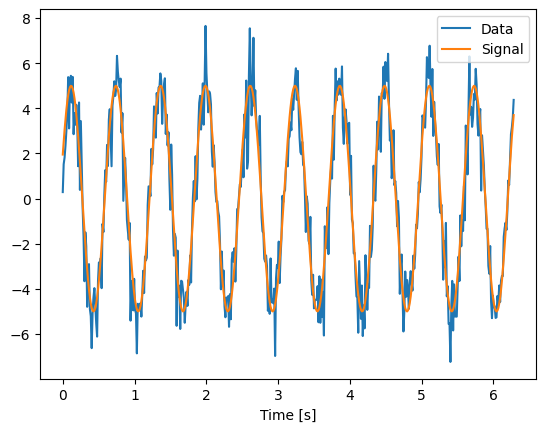

In [5]:
print('injected [amplitude, frequency, phase] =', real_vals)
plt.plot(x, data, label='Data')
plt.plot(x, sinusoidal_model(np.array(real_vals), x), label='Signal')
plt.legend()
plt.xlabel('Time [s]')

Now we'll do a grid approximation of the likelihood function to get the posterior distribution of the parameters $A$, $f$, and $\phi$.

In [6]:
lnlikelihood = VectorizedLnLikelihood(x, data)
sampler = PTSampler(3, lnlikelihood, vectorized_log_prior, ntemps=20, swap_steps=1, inf_temp=True, vectorized=True)
# sampler = PTSampler(3, lnlikelihood, vectorized_log_prior, ntemps=10, swap_steps=10, inf_temp=True, vectorized=False)

In [7]:
# linear scaling with number of temperatures when likelihood is fast
sampler.sample([1, 1, 1], num_iterations=100_000, thin=1)
# sampler.sample([1, 1, 1], num_iterations=100_000, thin=10)

Sampling: 100%|██████████| 100000/100000 [01:15<00:00, 1326.98it/s]


In [ ]:
from impulse import autocorr_length_ips_ims

In [ ]:
chain_data = sampler.load_chain()
chains = [chain_data['samples'][i] for i in range(sampler.ntemps)]

In [ ]:
autocorr_length_ips_ims(chains[0][20_000:])

In [11]:
from emcee.autocorr import integrated_time

In [13]:
chains[0][1000::1].shape

(99000, 7)

In [18]:
np.array([integrated_time(chains[0][20_000::1, i]) for i in range(chains[0].shape[1])])

/Users/aaron/miniconda3/envs/impulse_test/lib/python3.13/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]


array([[4.39873504],
       [3.77314381],
       [3.72308389],
       [3.82588177],
       [3.82588177],
       [1.01231299],
       [       nan]])

## Compare the true values to the chains

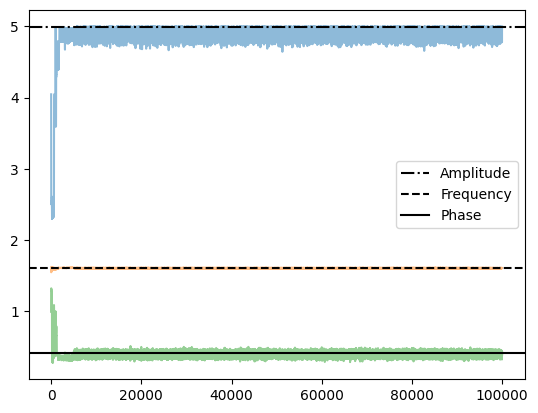

In [16]:
plt.plot(chains[0][:, 0], alpha = 0.5)
plt.axhline(amp_real, color='k', linestyle='-.', label="Amplitude")
plt.plot(chains[0][:, 1], alpha = 0.5)
plt.axhline(freq_real, color='k', linestyle='--', label="Frequency")
plt.plot(chains[0][:, 2], alpha = 0.5)
plt.axhline(phase_real, color='k', linestyle='-', label="Phase")
plt.legend()